In [127]:
tester = Tester()
content = tester.get_dataset_content()

print("Number of characters in dataset:", len(content))
print(content[:500])


Number of characters in dataset: 27418
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0;0;18;0;1;1;4;4;5;0;4;;2;2;0;0;1;1;1;0;0;1;1;4;3;4;1;1;3;6;14;15;15
0;0;17;0;1;0;1;1;5;3;4;1;1;2;0;1;0;1;1;1;0;0;1;5;3;3;1;1;3;4;6;6;7
0;0;15;0;0;0;1;1;5;;3;;1;2;3;0;1;0;1;0;0;0;1;4;3;2;2;3;3;10;7;7;8
0;0;15;0;1;0;4;2;1;4;0;;1;3;0;1;0;0;0;0;0;0;0;3;2;2;1;1;5;2;15;15;15
0


In [128]:
# implement your solution BELOW

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
dataset = content.strip().split('\n')
dataset = dataset[1:]
rows = []
for line in dataset:
    values = line.split(';')
    row = [np.nan if v == '' else float(v) for v in values]
    rows.append(row)
dataset_noisy = np.array(rows, dtype=np.float32)
print(dataset_noisy)

# implement your solution ABOVE

tester.test('dataset_load', dataset_noisy)

[[ 0.  0. 18. ... 14. 15. 15.]
 [ 0.  0. 17. ...  6.  6.  7.]
 [ 0.  0. 15. ...  7.  7.  8.]
 ...
 [ 1.  1. 21. ...  9.  8.  7.]
 [ 1.  1. 18. ... 12. 12. 11.]
 [ 1.  1. 19. ...  8.  9.  9.]]
Tester: Dataset loading OK


## **B**: Handling missing data

We will not be able to continue working with NaN values, because most NumPy/PyTorch operations do not support them, and for any array that contains at least one NaN value, the output of these operations will also become NaN, including for example our neural network's prediction and loss. The latter would prevent us from optimizing the network using gradient-based methods. Therefore, we will eliminate the NaN values representing missing data in the following way:

**For each variable that may contain NaN values, create a new variable indicating whether a valid value is present for that variable in the given sample or not.** If a valid value is present, the new variable should take the value 1; in the NaN case, it should take the value 0. Place the original data and the new variables into the `dataset` array: the columns of the new variables must be appended **after** all columns containing the original variables, in the appropriate order! The previous task description mentioned which columns may contain NaN values.</br>
Since columns (variables) with indices #8, #9, and #11 in our 33-variable dataset may contain NaN values, the new `dataset` array will have 36 variables, and the three new variables will be placed in the last three columns. For example, in column #33, a row should contain 0 if the same row in column #8 contains NaN, and 1 otherwise. Similarly, create columns #34 and #35 based on columns #9 and #11.

Finally, **replace all NaN values in the resulting array with zeros!**


In [129]:
# implement your solution BELOW

colums = [8, 9, 11] # with missing values

indicators = np.where(np.isnan(dataset_noisy[:, colums]), 0, 1).astype(np.float32);

dataset = np.concatenate([dataset_noisy, indicators], axis=1)

dataset = np.where(np.isnan(dataset), 0, dataset).astype(np.float32)

print(dataset.shape)

print(np.isnan(dataset).sum())

# implement your solution ABOVE

tester.test('dataset_fill_missing', dataset)

(395, 36)
0
Tester: Dataset fill missing OK


## **C**: Splitting into training, validation, and test sets

**Randomly shuffle the samples** in the `dataset` array. In general, this is advisable because the samples in the dataset may be ordered according to some property. Without shuffling, the label distributions in the resulting splits could differ significantly.

After that, **split the array into training, validation, and test sets** in a 50%, 25%, 25% ratio. Name the three arrays containing these sets `dataset_split_train`, `dataset_split_val`, and `dataset_split_test`, respectively!


In [130]:
# implement your solution BELOW

np.random.seed(42)
np.random.shuffle(dataset)

n = dataset.shape[0] # Define n as the number of samples in the dataset

# Split points
train_end = int(n * 0.5)
val_end = int(n * 0.75)

# Split dataset _train, validation and test

dataset_split_train = dataset[:train_end] # 50%
dataset_split_val   = dataset[train_end:val_end] # 25%
dataset_split_test  = dataset[val_end:] # 25%

# Print results

print("Train:", dataset_split_train.shape)
print("Validation:", dataset_split_val.shape)
print("Test:", dataset_split_test.shape)

# implement your solution ABOVE

tester.test('dataset_split', dataset_split_train, dataset_split_val, dataset_split_test)

Train: (197, 36)
Validation: (99, 36)
Test: (99, 36)
Tester: Dataset split OK


## **D**: Creating data iterators for the regression task

Gradient-based training of neural networks is most often implemented using iterators that traverse the dataset and produce the input and label batches required for training. In the regression task, the target label variable to be estimated will be the students' final grades (the column named `G3` in the original dataset text file, i.e. the column with index 32), while the input variables will be all other attributes, including the three newly created variables.

In this subtask, **you need to create three iterator objects** named `dataloader_reg_train`, `dataloader_reg_val`, and `dataloader_reg_test`, which traverse the arrays containing the training, validation, and test sets created in the previous subtask. **At each step, the iterators must return two tensors**, storing one batch of input data and one batch of label data, respectively. Therefore, the shapes of the returned tensors will be `(batch_size, 35)` and `(batch_size, 1)`. The latter tensor (containing the labels) will store the students' final grades, while the former will store the values of all other dataset variables for the corresponding samples. `batch_size` denotes the number of samples that our neural network receives at once in a single batch, for example 32.

It is important to emphasize that the iterators should already return sample batches derived from the above NumPy arrays (`np.ndarray`) as `torch.tensor` objects (more precisely, as two-element tuples containing `torch.tensor` objects), since training neural networks defined in PyTorch definitely requires PyTorch tensors. The tensors must use the **data type** 4-byte floating point, i.e. `torch.float32`.

The iterators enumerating the **training and validation sets must traverse their samples in random order**. The iterator enumerating the test set must not change the order of the `dataset_split_test` array!

The implementation of the iterators can be solved in several ways. For example, by creating a custom generator/iterator, or by using and possibly subclassing the `Dataset` and `DataLoader` classes from the `torch.utils.data` module.


In [131]:
# implement your solution BELOW

import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

# Regression Task _ split data at 32 (instruction)

X_train = np.delete(dataset_split_train, 32, axis=1)
y_train = dataset_split_train[:, [32]]

X_val = np.delete(dataset_split_val, 32, axis=1)
y_val = dataset_split_val[:, [32]]

X_test = np.delete(dataset_split_test, 32, axis=1)
y_test = dataset_split_test[:, [32]]

# 2. Convert to PyTorch Tensors with torch.float32

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 3. Create DataLoaders

dataloader_reg_train = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
dataloader_reg_val   = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=batch_size, shuffle=True)
dataloader_reg_test  = DataLoader(TensorDataset(X_test_t, y_test_t),  batch_size=batch_size, shuffle=False)

# implement your solution ABOVE

tester.test('reg_iter', dataloader_reg_train, dataloader_reg_val, dataloader_reg_test)

Tester: Dataset iterators for regression task OK


## **E**: Defining the regression neural network

**Define the class implementing the neural network to be used for the regression task**, as a subclass of the general `torch.nn.Module` class, then instantiate it and assign the instance to the variable `reg_model`!

The regression neural network must **contain 3 fully connected layers with 25, 25, and 1 neurons, respectively, and apply the ReLU activation function between the layers!**

The new class must implement the member function `forward(self, x)`, which evaluates the neural network (hypothesis function) on the input tensor `x`. The `forward` function will receive the input tensors coming from the data iterator defined earlier and produce the label predictions from them. It is advisable to initialize the layers of the neural network in the constructor of the class.


In [132]:
# implement your solution BELOW

import torch.nn as nn

class RegressionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(35, 25) # first layer based on instruction
        self.fc2 = nn.Linear(25, 25) # 2nd layer
        self.fc3 = nn.Linear(25, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

reg_model = RegressionNet()

# implement your solution ABOVE

tester.test('reg_model_architecture', reg_model)

Tester: Regression model architecture OK


## **F**: Training the network for the regression task

**Train the** `reg_model` **neural network** on the training set using the `dataloader_reg_train` iterator, and use the `dataloader_reg_val` iterator for validation. A single full pass through the training and validation datasets by the iterators (even in random order) defines one _epoch_.

Use the **mean squared error (MSE) loss**, which is commonly used for regression. **Measure the training and validation losses in every epoch, then after training, plot how these values changed during training on a shared plot.** To produce the plots, you may for example use the `matplotlib` library. Make sure that the differences between the curves remain clearly visible on the plot even near the end of training. If necessary, you may manually set which portion of the y-axis the plot displays. **The plot must include a legend** indicating which curve corresponds to the training loss and which to the validation loss.

You may determine the training duration (the number of epochs) manually based on the validation loss curve: try to choose it so that the neural network is trained well, but severe overfitting has not yet appeared.

For training, choose a gradient-based **optimization algorithm** from the `torch.optim` module (e.g. `SGD`, `Adam`, `RMSprop`, etc.), and also choose an appropriate **learning rate**.

After training, **measure the average loss on the full test set** and assign the resulting value to the variable `test_mse`!

After that, **select a few samples from the test set** (for example using the `dataloader_reg_test` iterator), and **predict their labels** based on the values of the input variables, then **print the predicted and true labels for each sample**. This way, we can also see from examples how good the predictions of our neural network are.


Epoch 10/100 | Train MSE: 10.3846 | Val MSE: 8.8361
Epoch 20/100 | Train MSE: 6.0572 | Val MSE: 4.6027
Epoch 30/100 | Train MSE: 2.7606 | Val MSE: 2.6165
Epoch 40/100 | Train MSE: 1.5823 | Val MSE: 1.4576
Epoch 50/100 | Train MSE: 1.5354 | Val MSE: 1.4294
Epoch 60/100 | Train MSE: 1.2241 | Val MSE: 1.3364
Epoch 70/100 | Train MSE: 1.1750 | Val MSE: 1.3075
Epoch 80/100 | Train MSE: 1.0982 | Val MSE: 1.2438
Epoch 90/100 | Train MSE: 1.1097 | Val MSE: 1.2486
Epoch 100/100 | Train MSE: 1.1038 | Val MSE: 1.2572


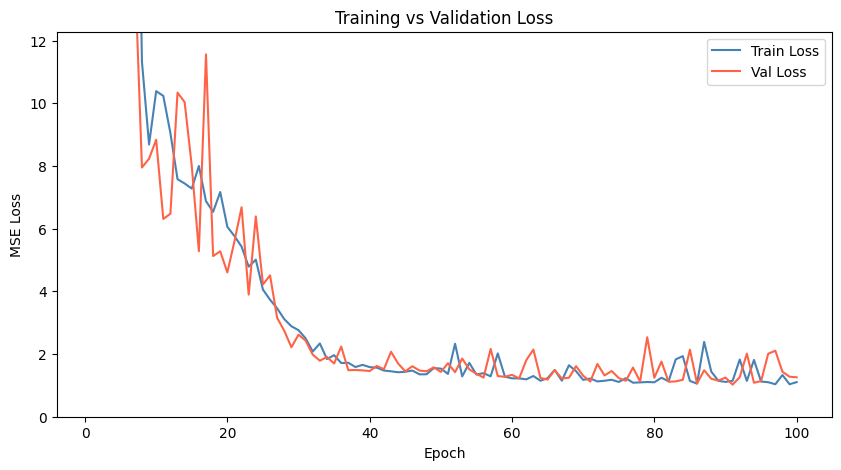


Test MSE: 1.2793

Predictions:
#         Predicted         True
--------------------------------
0           11.6118      12.0000
1            4.9006       3.0000
2           15.3066      15.0000
3            8.2483       8.0000
4            8.3922       9.0000
5           11.3379       9.0000
6            4.7986       3.0000
7           16.7892      19.0000
8           13.1322      13.0000
9           18.5832      19.0000


In [133]:
# implement your solution BELOW

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=0.001) # learning rate is 0.001

# 2. Setup
num_epochs = 100
train_losses = []
val_losses = []
device = next(reg_model.parameters()).device

# 3. Training loop
for epoch in range(1, num_epochs + 1):

    # Train
    reg_model.train()
    running_train_loss = 0.0
    train_batches = 0

    for X_batch, y_batch in dataloader_reg_train:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = reg_model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_batches += 1

    avg_train_loss = running_train_loss / train_batches

    #Validate
    reg_model.eval()
    running_val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader_reg_val:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = reg_model(X_batch)
            loss = criterion(predictions, y_batch)
            running_val_loss += loss.item()
            val_batches += 1

    avg_val_loss = running_val_loss / val_batches

    # Save losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

# 4. Plot losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", color="steelblue")
plt.plot(range(1, num_epochs + 1), val_losses,   label="Val Loss",   color="tomato")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.ylim(0, max(train_losses[10], val_losses[10]) * 1.2)
plt.show()

# 5. Test MSE
reg_model.eval()
total_test_loss = 0.0
test_batches = 0

with torch.no_grad():
    for X_batch, y_batch in dataloader_reg_test:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = reg_model(X_batch)
        loss = criterion(predictions, y_batch)
        total_test_loss += loss.item()
        test_batches += 1

test_mse = total_test_loss / test_batches
print(f"\nTest MSE: {test_mse:.4f}")

# 6. Predictions
print("\nPredictions:")
print(f"{'#':<6} {'Predicted':>12} {'True':>12}")
print("-" * 32)

with torch.no_grad():
    X_sample, y_sample = next(iter(dataloader_reg_test))
    X_sample = X_sample.to(device)
    preds = reg_model(X_sample).cpu()

    for i in range(min(10, len(y_sample))):
        print(f"{i:<6} {preds[i].item():>12.4f} {y_sample[i].item():>12.4f}")

# implement your solution ABOVE

So, predicted value and True values are not quite different which indicates that the data is working really well.

## **G**: Creating data iterators for the classification task

Similarly to task D, here we also need to create three data iterators. However, this time we will learn to solve a slightly different task, so the shapes / data types of the returned tensors will also differ. **Create** the **iterators** named `dataloader_cl_train`, `dataloader_cl_val`, and `dataloader_cl_test`, which should again traverse the arrays containing the training, validation, and test sets created in subtask C. In the classification task, we use all variables in the dataset as input variables except the students' three third-period grades (`G1`, `G2`, `G3`, the columns with indices #30, #31, and #32 in the original dataset text file). As labels, we define three categories and assign every student to one of them:
- **"Low-performing students"** category, category index #0: Students belong here if at least two of their grades are lower than 11.
- **"Moderately performing students"** category, category index #1: Students belong here if their average grade is lower than 14, but they do not belong to the "Low-performing students" category.
- **"High-performing students"** category, category index #2: Students belong here if they do not belong to either of the other two categories.

Based on the above, the tensors returned by the iterators will have shapes `(batch_size, 33)` and `(batch_size,)`. The latter tensor (containing the labels) will store the category indices of the students (that is, values 0, 1, or 2, with data type `torch.int64`), while the former will store the values of all used dataset variables for the corresponding samples with data type `torch.float32`. `batch_size` once again denotes the number of samples and must be set manually.

The iterators enumerating the **training and validation sets must traverse the corresponding samples in random order**. The iterator enumerating the test set must not change the order of the `dataset_split_test` array!


In [134]:
# implement your solution BELOW

# Classification Task

import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

def get_classification_label(grades):
    g1, g2, g3 = grades[0], grades[1], grades[2]
    low_grades_count = sum(1 for g in [g1, g2, g3] if g < 11)

    if low_grades_count >= 2:
        return 0 # Low-performing
    elif (g1 + g2 + g3) / 3 < 14:
        return 1 # Moderately performing
    else:
        return 2 # High-performing

# Data for classificaiton

def prepare_classification_data(dataset_split):

    X = np.delete(dataset_split, [30, 31, 32], axis=1)

    y_grades = dataset_split[:, [30, 31, 32]]
    y = np.array([get_classification_label(grades) for grades in y_grades], dtype=np.int64)

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.int64)

    return X_t, y_t
# Train
X_train_cl_t, y_train_cl_t = prepare_classification_data(dataset_split_train)

#Validation
X_val_cl_t, y_val_cl_t = prepare_classification_data(dataset_split_val)

# Test
X_test_cl_t, y_test_cl_t = prepare_classification_data(dataset_split_test)

# Dataloader for classificaiton task

dataloader_cl_train = DataLoader(TensorDataset(X_train_cl_t, y_train_cl_t), batch_size=batch_size, shuffle=True)
dataloader_cl_val   = DataLoader(TensorDataset(X_val_cl_t, y_val_cl_t),   batch_size=batch_size, shuffle=True)
dataloader_cl_test  = DataLoader(TensorDataset(X_test_cl_t, y_test_cl_t),  batch_size=batch_size, shuffle=False)

# implement your solution ABOVE

tester.test('cl_iter', dataloader_cl_train, dataloader_cl_val, dataloader_cl_test)

Tester: Dataset iterators for classification task OK


## **H**: Defining the classification neural network

**Define the class implementing the neural network to be used for the classification task**, which, similarly to the class implementing the regression neural network, must be a subclass of the general `torch.nn.Module` class. Instantiate the new class and assign the instance to the variable `cl_model`!

The classification neural network must **contain 3 fully connected layers. The first two layers must contain 30 and 20 neurons, respectively, and apply the ReLU activation function after these layers.** The final layer must be designed for three-class classification!


In [135]:
# implement your solution BELOW

class ClassificationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(33, 30)  # 33 inputs → 30 neurons
        self.layer2 = nn.Linear(30, 20)  # 30 → 20 neurons
        self.layer3 = nn.Linear(20, 3)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.layer3(x)
        return x

cl_model = ClassificationNet()

# implement your solution ABOVE

tester.test('cl_model_architecture', cl_model)

Tester: Classification model architecture OK


## **I**: Training the network for the multi-class classification task

**Train the** `cl_model` **neural network** on the training set using the `dataloader_cl_train` iterator, and use the `dataloader_cl_val` iterator for validation!

Use the **cross-entropy (CE) loss**, which is commonly used in multi-class classification. **Measure the training and validation losses in every epoch, then after training plot how these values changed during training on a shared plot.** On the plot, again make sure that there is a legend and that the curves are easy to distinguish.

This time, training must be stopped using the **early stopping** technique. If the validation loss does not improve for a given number of epochs (`patience`), training should end, and **the weights of `cl_model` must be restored from the epoch in which the validation loss was best!** This must happen automatically.

After training, **measure the average loss on the full test set** and assign the resulting value to the variable `test_ce`!

**Also compute the _accuracy_ metric on the test set samples** and assign the resulting value to the variable `test_acc`!! The _accuracy_ metric gives the proportion of correctly classified samples. For example, if while predicting the categories of 150 samples we correctly identify the right category in 75 cases, then the value of _accuracy_ is 0.5.

After that, **select a few samples from the test set** (for example using the `dataloader_cl_test` iterator), and **predict their labels** (their category indices) based on the values of the input variables, then **print the predicted and true labels for each sample** (the category indices). This way, we can also see from examples how good the predictions of our neural network are.

Finally, **compute the confusion matrix of the network on the test set and plot it**! The confusion matrix is a k x k matrix for k categories, where the element at index `[i,j]` gives how many samples belonging to category `i` in the dataset were predicted by our model as category `j`. Good model performance is indicated when as many elements as possible fall on the main diagonal of the confusion matrix. For the computation, you may also use an external library, but it can be done in NumPy as well. For plotting, you may for example use the `imshow` function from `matplotlib.pyplot`. Make sure that it is clearly visible on the plot which axis lists the true categories and which lists the predicted categories, that the category indices are visible at the ends of the rows and columns, and that the cells contain the corresponding sample counts!


Stopped at epoch 13


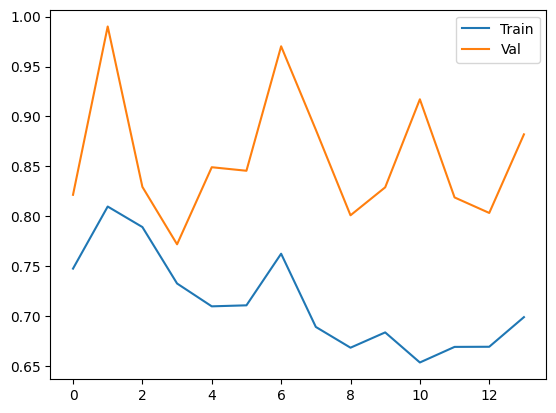

Test CE:  0.8635
Test Acc: 0.5152
Predicted: 0  |  True: 1
Predicted: 0  |  True: 0
Predicted: 2  |  True: 2
Predicted: 0  |  True: 0
Predicted: 0  |  True: 0


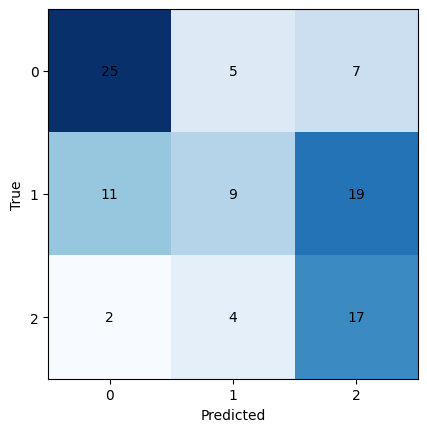

Tester: Classification model learning OK


In [139]:
# implement your solution BELOW

# MLP Classification
import copy
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(cl_model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()
epochs    = 200
patience  = 10

train_losses      = []
val_losses        = []
best_val_loss     = float('inf')
best_weights      = None
no_improve_count  = 0

# training loop
for epoch in range(epochs):

    # training
    cl_model.train()
    train_loss = 0
    for X_batch, y_batch in dataloader_cl_train:
        optimizer.zero_grad()
        pred  = cl_model(X_batch)
        loss  = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    cl_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader_cl_val:
            pred      = cl_model(X_batch)
            loss      = loss_fn(pred, y_batch)
            val_loss += loss.item()

    avg_train = train_loss / len(dataloader_cl_train)
    avg_val   = val_loss   / len(dataloader_cl_val)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # early stopping
    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        best_weights     = copy.deepcopy(cl_model.state_dict())
        no_improve_count = 0
    else:
        no_improve_count += 1

    if no_improve_count == patience:
        print(f"Stopped at epoch {epoch}")
        break

cl_model.load_state_dict(best_weights)

# plot
plt.plot(train_losses, label="Train")
plt.plot(val_losses,   label="Val")
plt.legend()
plt.show()

# test loss and accuracy
cl_model.eval()
test_loss = 0
correct   = 0
total     = 0

with torch.no_grad():
    for X_batch, y_batch in dataloader_cl_test:
        pred       = cl_model(X_batch)
        test_loss += loss_fn(pred, y_batch).item()
        predicted  = torch.argmax(pred, dim=1)
        correct   += (predicted == y_batch).sum().item()
        total     += len(y_batch)

test_ce  = test_loss / len(dataloader_cl_test)
test_acc = correct / total
print(f"Test CE:  {test_ce:.4f}")
print(f"Test Acc: {test_acc:.4f}")

# Predictions
X_sample, y_sample = next(iter(dataloader_cl_test))
with torch.no_grad():
    predicted = torch.argmax(cl_model(X_sample), dim=1)
for i in range(5):
    print(f"Predicted: {predicted[i].item()}  |  True: {y_sample[i].item()}")

# confusion matrix
all_preds  = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in dataloader_cl_test:
        predicted = torch.argmax(cl_model(X_batch), dim=1)
        all_preds.append(predicted.numpy())
        all_labels.append(y_batch.numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

confusion = np.zeros((3, 3), dtype=int)
for true, pred in zip(all_labels, all_preds):
    confusion[true][pred] += 1

plt.imshow(confusion, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion[i][j], ha='center', va='center')

plt.show()
# implement your solution ABOVE

tester.test('cl_model_learning', test_ce, test_acc)